# 06 - Benchmark estadistico y resultados finales

Este notebook consolida el benchmark final de segmentacion semantica sobre AI4MARS. Consume los artefactos producidos por los notebooks `05a`-`05e` y genera la comparacion cuantitativa, el ranking, los trade-offs de costo y las pruebas estadisticas exigidas por el entregable.

Entradas esperadas:

- `results/benchmark_results.csv`: metricas agregadas por modelo.
- Resultados por seed extraibles de los outputs ejecutados de `notebooks/05a`-`05e`, o un archivo `results/benchmark_per_seed.csv` con columnas `model`, `seed`, `mIoU`.

Reglas experimentales usadas en todo el benchmark: mismo split train/val, mismo gold test set MSL min3, mismas seeds `[42, 123, 7]`, misma normalizacion calculada solo con train y metricas sobre pixeles validos (`ignore_index=255`).

## Que incluye este notebook

1. Validacion del CSV agregado y ordenamiento por mIoU.
2. Tabla comparativa final con media, desviacion estandar, IC95, IoU por clase, parametros y tiempo.
3. Ranking visual con intervalos de confianza.
4. Analisis por clase, con foco especial en `big_rock` por ser la clase minoritaria.
5. Trade-off rendimiento vs parametros y rendimiento vs tiempo de entrenamiento.
6. Extraccion de resultados por seed para inferencia estadistica.
7. Friedman global, Nemenyi post-hoc, comparaciones pareadas con normalidad y correccion de Holm.
8. Resumen ejecutivo calculado dinamicamente desde los resultados finales.

In [1]:
from pathlib import Path
import json
import re
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

print("Librerias cargadas.")

Librerias cargadas.


In [2]:
def find_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / "results" / "benchmark_results.csv").exists() and (p / "notebooks").exists():
            return p
    raise FileNotFoundError("No se encontro la raiz del proyecto con results/benchmark_results.csv y notebooks/.")

ROOT = find_root()
NOTEBOOKS_DIR = ROOT / "notebooks"
RESULTS_DIR = ROOT / "results"
BENCHMARK_CSV = RESULTS_DIR / "benchmark_results.csv"
PER_SEED_CSV = RESULTS_DIR / "benchmark_per_seed.csv"

EXPECTED_MODELS = ["DeepLabV3+", "SegFormer-B2", "MarsSeg", "TerSeg", "DepthFormer-RGB"]
SEEDS = [42, 123, 7]
CLASS_COLS = ["iou_soil_mean", "iou_bedrock_mean", "iou_sand_mean", "iou_big_rock_mean"]
CLASS_LABELS = ["soil", "bedrock", "sand", "big_rock"]
ALPHA = 0.05

COLORS = {
    "DeepLabV3+": "#C73E3A",
    "SegFormer-B2": "#2F80ED",
    "MarsSeg": "#D99021",
    "TerSeg": "#2E9D63",
    "DepthFormer-RGB": "#7A5CCF",
}

MODEL_INFO = pd.DataFrame([
    {"model": "DeepLabV3+", "familia": "CNN", "arquitectura": "ResNet-50 + ASPP", "paper_base": "Mohammad et al. (2024)"},
    {"model": "SegFormer-B2", "familia": "Transformer", "arquitectura": "MiT-B2 + decoder MLP", "paper_base": "Xie et al. (2021)"},
    {"model": "MarsSeg", "familia": "CNN avanzado", "arquitectura": "ResNet-50 + MiniASPP + PSA + SPPM", "paper_base": "Li et al. (2024)"},
    {"model": "TerSeg", "familia": "Hibrido CNN+Transformer", "arquitectura": "ResNet-34 + Swin-Tiny + FLGA", "paper_base": "Fan et al. (2025)"},
    {"model": "DepthFormer-RGB", "familia": "Transformer", "arquitectura": "Swin-Tiny + UPerNet + PPM", "paper_base": "Ma et al. (2025)"},
])

print(f"ROOT: {ROOT}")
print(f"CSV agregado: {BENCHMARK_CSV}")

ROOT: c:\Users\User\Documents\DeepLearning\ai4mars_DL-v3
CSV agregado: c:\Users\User\Documents\DeepLearning\ai4mars_DL-v3\results\benchmark_results.csv


## Carga y validacion de resultados agregados

In [3]:
required_cols = {
    "model", "mIoU_mean", "mIoU_std", "mIoU_ci95", "pixel_acc_mean",
    "iou_soil_mean", "iou_soil_std", "iou_bedrock_mean", "iou_bedrock_std",
    "iou_sand_mean", "iou_sand_std", "iou_big_rock_mean", "iou_big_rock_std",
    "params_M", "train_time_mean_s", "best_epoch_mean",
}

df = pd.read_csv(BENCHMARK_CSV)
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"Faltan columnas requeridas en benchmark_results.csv: {sorted(missing_cols)}")

dupes = df[df["model"].duplicated(keep=False)]
if not dupes.empty:
    raise ValueError("Hay modelos duplicados en benchmark_results.csv. Limpia el CSV antes del benchmark final.")

missing_models = set(EXPECTED_MODELS) - set(df["model"])
extra_models = set(df["model"]) - set(EXPECTED_MODELS)
if missing_models or extra_models:
    raise ValueError(f"Modelos esperados faltantes={sorted(missing_models)} | modelos extra={sorted(extra_models)}")

df = df.merge(MODEL_INFO, on="model", how="left")
df["train_time_mean_min"] = df["train_time_mean_s"] / 60
df["rank_mIoU"] = df["mIoU_mean"].rank(ascending=False, method="min").astype(int)
df_sorted = df.sort_values("mIoU_mean", ascending=False).reset_index(drop=True)
df_sorted.insert(0, "rank", np.arange(1, len(df_sorted) + 1))

display(df_sorted[[
    "rank", "model", "familia", "arquitectura", "mIoU_mean", "mIoU_std", "mIoU_ci95",
    "pixel_acc_mean", "iou_soil_mean", "iou_bedrock_mean", "iou_sand_mean", "iou_big_rock_mean",
    "params_M", "train_time_mean_min", "best_epoch_mean",
]])

,rank,model,familia,arquitectura,mIoU_mean,mIoU_std,mIoU_ci95,pixel_acc_mean,iou_soil_mean,iou_bedrock_mean,iou_sand_mean,iou_big_rock_mean,params_M,train_time_mean_min,best_epoch_mean
0,1,TerSeg,Hibrido CNN+Transformer,ResNet-34 + Swin-Tiny + FLGA,0.8381,0.0297,0.0336,0.9775,0.9805,0.9188,0.9433,0.5097,49.19,49.866667,38.0
1,2,SegFormer-B2,Transformer,MiT-B2 + decoder MLP,0.8337,0.0063,0.0071,0.9814,0.9783,0.9397,0.9575,0.4592,27.35,70.683333,25.0
2,3,DeepLabV3+,CNN,ResNet-50 + ASPP,0.8183,0.0198,0.0224,0.9794,0.9751,0.9387,0.9517,0.4079,42.00,154.016667,32.7
3,4,DepthFormer-RGB,Transformer,Swin-Tiny + UPerNet + PPM,0.7219,0.0290,0.0328,0.9554,0.9405,0.8960,0.8976,0.1535,42.02,1.900000,16.0
4,5,MarsSeg,CNN avanzado,ResNet-50 + MiniASPP + PSA + SPPM,0.7054,0.0318,0.0360,0.9416,0.9145,0.8714,0.8627,0.1731,34.87,4.016667,38.0


## Tabla final de benchmark

In [4]:
table = df_sorted.copy()
table["mIoU (mean +/- std)"] = table.apply(lambda r: f"{r['mIoU_mean']:.4f} +/- {r['mIoU_std']:.4f}", axis=1)
table["IC95"] = table["mIoU_ci95"].map(lambda x: f"+/- {x:.4f}")
table["Pixel Acc"] = table["pixel_acc_mean"].map(lambda x: f"{x:.4f}")
table["IoU soil"] = table["iou_soil_mean"].map(lambda x: f"{x:.4f}")
table["IoU bedrock"] = table["iou_bedrock_mean"].map(lambda x: f"{x:.4f}")
table["IoU sand"] = table["iou_sand_mean"].map(lambda x: f"{x:.4f}")
table["IoU big_rock"] = table["iou_big_rock_mean"].map(lambda x: f"{x:.4f}")
table["Params (M)"] = table["params_M"].map(lambda x: f"{x:.2f}")
table["Train time (min)"] = table["train_time_mean_min"].map(lambda x: f"{x:.1f}")

display(table[[
    "rank", "model", "paper_base", "mIoU (mean +/- std)", "IC95", "Pixel Acc",
    "IoU soil", "IoU bedrock", "IoU sand", "IoU big_rock", "Params (M)", "Train time (min)",
]].rename(columns={"rank": "Rank", "model": "Modelo", "paper_base": "Paper base"}).set_index("Rank"))

,Modelo,Paper base,mIoU (mean +/- std),IC95,Pixel Acc,IoU soil,IoU bedrock,IoU sand,IoU big_rock,Params (M),Train time (min)
Rank,,,,,,,,,,,
1,TerSeg,Fan et al. (2025),0.8381 +/- 0.0297,+/- 0.0336,0.9775,0.9805,0.9188,0.9433,0.5097,49.19,49.9
2,SegFormer-B2,Xie et al. (2021),0.8337 +/- 0.0063,+/- 0.0071,0.9814,0.9783,0.9397,0.9575,0.4592,27.35,70.7
3,DeepLabV3+,Mohammad et al. (2024),0.8183 +/- 0.0198,+/- 0.0224,0.9794,0.9751,0.9387,0.9517,0.4079,42.00,154.0
4,DepthFormer-RGB,Ma et al. (2025),0.7219 +/- 0.0290,+/- 0.0328,0.9554,0.9405,0.8960,0.8976,0.1535,42.02,1.9
5,MarsSeg,Li et al. (2024),0.7054 +/- 0.0318,+/- 0.0360,0.9416,0.9145,0.8714,0.8627,0.1731,34.87,4.0


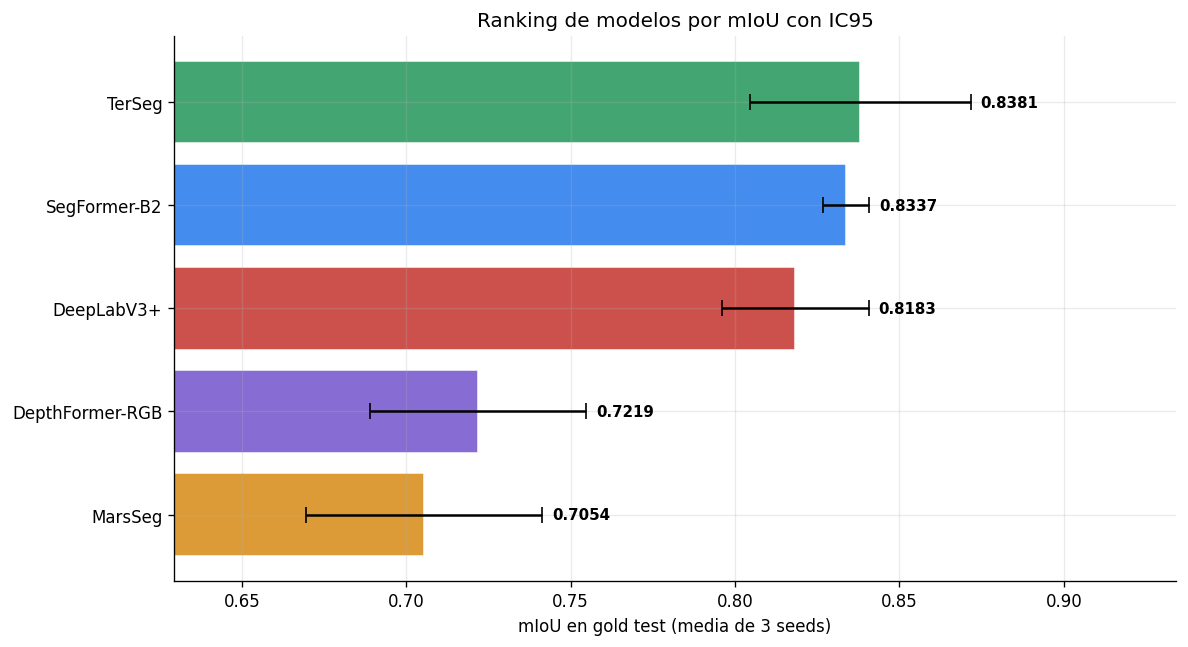

In [5]:
fig, ax = plt.subplots(figsize=(10, 5.5))
ranked = df_sorted.iloc[::-1]
bar_colors = [COLORS[m] for m in ranked["model"]]
bars = ax.barh(ranked["model"], ranked["mIoU_mean"], xerr=ranked["mIoU_ci95"],
               color=bar_colors, alpha=0.9, edgecolor="white",
               error_kw={"capsize": 5, "linewidth": 1.5})

for bar, mean, ci in zip(bars, ranked["mIoU_mean"], ranked["mIoU_ci95"]):
    ax.text(mean + ci + 0.003, bar.get_y() + bar.get_height() / 2,
            f"{mean:.4f}", va="center", ha="left", fontsize=9, fontweight="bold")

xmin = max(0.0, df_sorted["mIoU_mean"].min() - df_sorted["mIoU_ci95"].max() - 0.04)
xmax = min(1.0, df_sorted["mIoU_mean"].max() + df_sorted["mIoU_ci95"].max() + 0.06)
ax.set_xlim(xmin, xmax)
ax.set_xlabel("mIoU en gold test (media de 3 seeds)")
ax.set_title("Ranking de modelos por mIoU con IC95")
plt.tight_layout()
plt.show()

## Analisis por clase

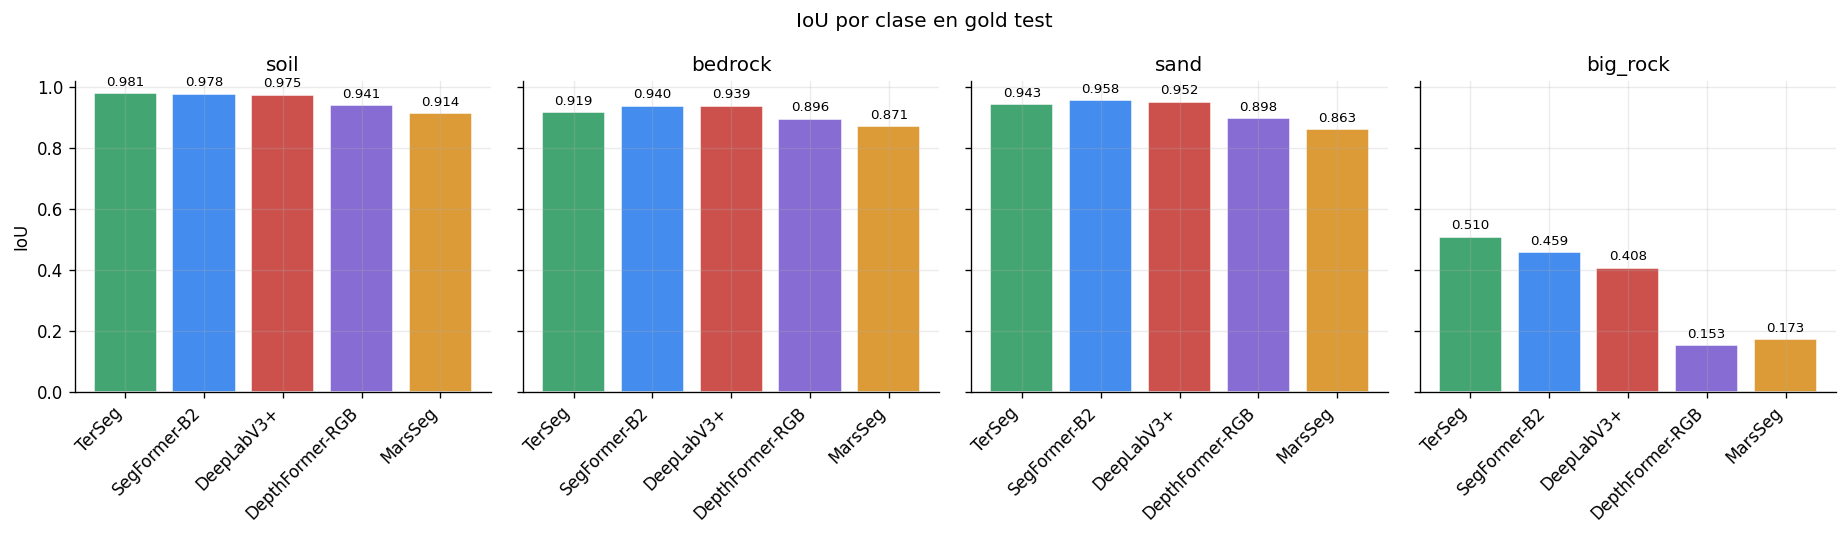

,class,model,IoU
0,bedrock,SegFormer-B2,0.9397
1,big_rock,TerSeg,0.5097
2,sand,SegFormer-B2,0.9575
3,soil,TerSeg,0.9805


,class,IoU
0,big_rock,0.34068
1,bedrock,0.91292
2,sand,0.92256
3,soil,0.95778


In [6]:
class_long = df_sorted.melt(
    id_vars=["model"],
    value_vars=CLASS_COLS,
    var_name="class_col",
    value_name="IoU",
)
class_long["class"] = class_long["class_col"].map(dict(zip(CLASS_COLS, CLASS_LABELS)))

fig, axes = plt.subplots(1, 4, figsize=(15.5, 4.5), sharey=True)
for ax, class_name, col in zip(axes, CLASS_LABELS, CLASS_COLS):
    tmp = df_sorted[["model", col]].copy()
    bars = ax.bar(tmp["model"], tmp[col], color=[COLORS[m] for m in tmp["model"]], alpha=0.9, edgecolor="white")
    ax.set_title(class_name)
    ax.set_ylim(0, 1.02)
    ax.tick_params(axis="x", labelrotation=45)
    for label in ax.get_xticklabels():
        label.set_ha("right")
    for bar, val in zip(bars, tmp[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.015, f"{val:.3f}", ha="center", va="bottom", fontsize=8)
axes[0].set_ylabel("IoU")
plt.suptitle("IoU por clase en gold test")
plt.tight_layout()
plt.show()

best_by_class = class_long.loc[class_long.groupby("class")["IoU"].idxmax(), ["class", "model", "IoU"]]
worst_class_mean = class_long.groupby("class")["IoU"].mean().sort_values().reset_index()
display(best_by_class.sort_values("class").reset_index(drop=True))
display(worst_class_mean)

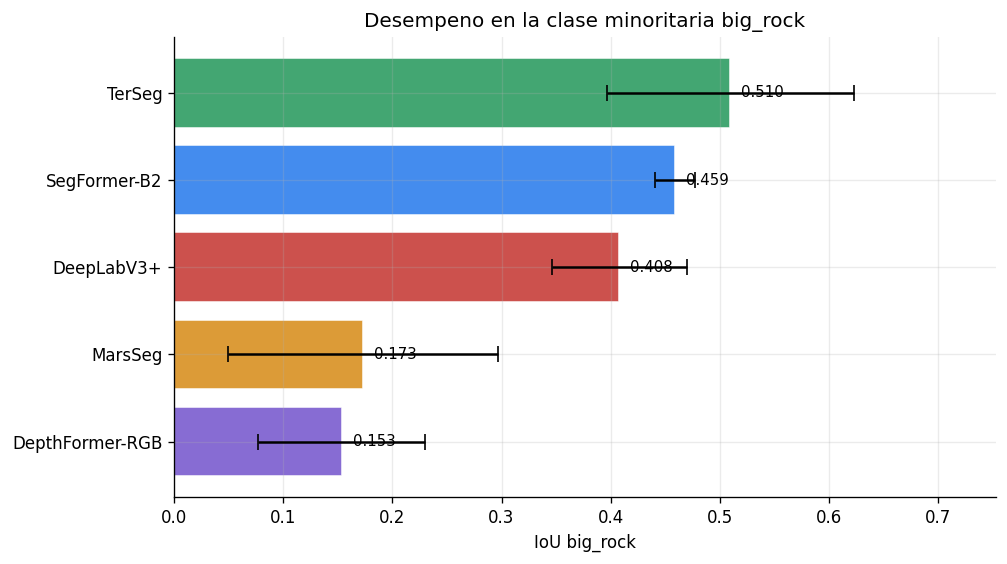

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
tmp = df_sorted.sort_values("iou_big_rock_mean", ascending=True)
bars = ax.barh(tmp["model"], tmp["iou_big_rock_mean"],
               xerr=tmp["iou_big_rock_std"], color=[COLORS[m] for m in tmp["model"]],
               alpha=0.9, edgecolor="white", error_kw={"capsize": 5})
for bar, val in zip(bars, tmp["iou_big_rock_mean"]):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2, f"{val:.3f}", va="center", fontsize=9)
ax.set_xlabel("IoU big_rock")
ax.set_title("Desempeno en la clase minoritaria big_rock")
ax.set_xlim(0, min(1, tmp["iou_big_rock_mean"].max() + tmp["iou_big_rock_std"].max() + 0.12))
plt.tight_layout()
plt.show()

## Trade-off entre rendimiento, complejidad y costo

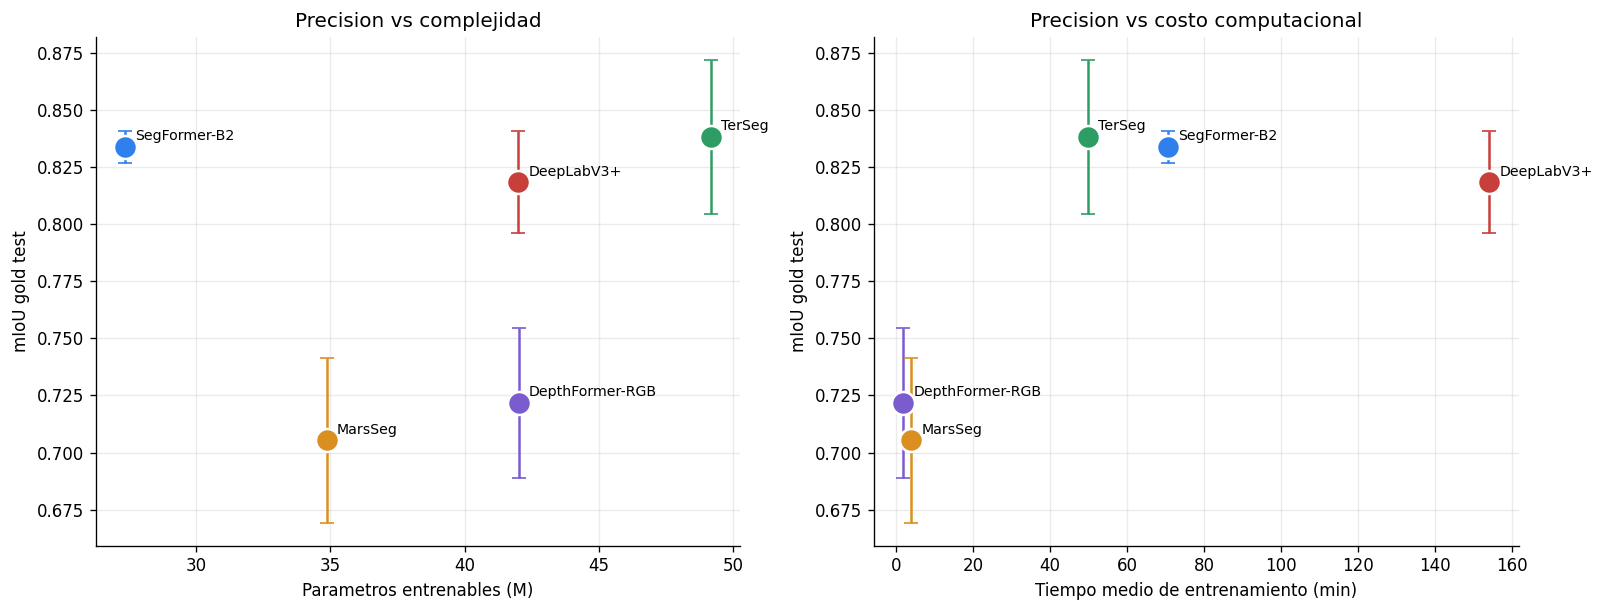

Modelo con mejor balance dentro de 1 punto de mIoU del lider: SegFormer-B2 (27.35M params, 70.7 min).


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))

for _, r in df_sorted.iterrows():
    color = COLORS[r["model"]]
    axes[0].scatter(r["params_M"], r["mIoU_mean"], s=190, color=color, edgecolor="white", linewidth=1.5, zorder=4)
    axes[0].errorbar(r["params_M"], r["mIoU_mean"], yerr=r["mIoU_ci95"], fmt="none", color=color, capsize=4)
    axes[0].annotate(r["model"], (r["params_M"], r["mIoU_mean"]), xytext=(6, 4), textcoords="offset points", fontsize=8.5)

    axes[1].scatter(r["train_time_mean_min"], r["mIoU_mean"], s=190, color=color, edgecolor="white", linewidth=1.5, zorder=4)
    axes[1].errorbar(r["train_time_mean_min"], r["mIoU_mean"], yerr=r["mIoU_ci95"], fmt="none", color=color, capsize=4)
    axes[1].annotate(r["model"], (r["train_time_mean_min"], r["mIoU_mean"]), xytext=(6, 4), textcoords="offset points", fontsize=8.5)

axes[0].set_xlabel("Parametros entrenables (M)")
axes[0].set_ylabel("mIoU gold test")
axes[0].set_title("Precision vs complejidad")

axes[1].set_xlabel("Tiempo medio de entrenamiento (min)")
axes[1].set_ylabel("mIoU gold test")
axes[1].set_title("Precision vs costo computacional")

plt.tight_layout()
plt.show()

best_miou = df_sorted["mIoU_mean"].max()
efficient = df_sorted[df_sorted["mIoU_mean"] >= best_miou - 0.01].sort_values(["params_M", "train_time_mean_s"]).iloc[0]
print(f"Modelo con mejor balance dentro de 1 punto de mIoU del lider: {efficient['model']} ({efficient['params_M']:.2f}M params, {efficient['train_time_mean_min']:.1f} min).")

## Resultados por seed

In [9]:
MODEL_NOTEBOOKS = {
    "DeepLabV3+": NOTEBOOKS_DIR / "05a_model_deeplabv3plus.ipynb",
    "SegFormer-B2": NOTEBOOKS_DIR / "05b_model_segformer.ipynb",
    "MarsSeg": NOTEBOOKS_DIR / "05c_model_marsseg.ipynb",
    "TerSeg": NOTEBOOKS_DIR / "05d_model_terseg.ipynb",
    "DepthFormer-RGB": NOTEBOOKS_DIR / "05e_model_depthformer.ipynb",
}

def output_text_from_notebook(path: Path) -> str:
    nb = json.loads(path.read_text(encoding="utf-8"))
    chunks = []
    for cell in nb.get("cells", []):
        for out in cell.get("outputs", []):
            text = out.get("text")
            if isinstance(text, list):
                chunks.append("".join(text))
            elif isinstance(text, str):
                chunks.append(text)
            data = out.get("data", {})
            plain = data.get("text/plain") if isinstance(data, dict) else None
            if isinstance(plain, list):
                chunks.append("".join(plain))
            elif isinstance(plain, str):
                chunks.append(plain)
    return "\n".join(chunks)

def extract_per_seed_from_notebooks() -> pd.DataFrame:
    rows = []
    seed_pat = re.compile(r"Seed\s+(\d+)\s*\|")
    best_pat = re.compile(r"Mejor val mIoU=([0-9.]+)\s*\(epoch\s*(\d+)\)\s*\|\s*tiempo=([0-9.]+)s")
    test_pat = re.compile(r"Gold test mIoU=([0-9.]+)")

    for model, path in MODEL_NOTEBOOKS.items():
        if not path.exists():
            continue
        current_seed = None
        current_val = np.nan
        current_epoch = np.nan
        current_time = np.nan
        for line in output_text_from_notebook(path).splitlines():
            m_seed = seed_pat.search(line)
            if m_seed:
                current_seed = int(m_seed.group(1))
                current_val = np.nan
                current_epoch = np.nan
                current_time = np.nan
                continue
            m_best = best_pat.search(line)
            if m_best and current_seed is not None:
                current_val = float(m_best.group(1))
                current_epoch = int(m_best.group(2))
                current_time = float(m_best.group(3))
                continue
            m_test = test_pat.search(line)
            if m_test and current_seed is not None:
                rows.append({
                    "model": model,
                    "seed": current_seed,
                    "mIoU": float(m_test.group(1)),
                    "best_val_mIoU": current_val,
                    "best_epoch": current_epoch,
                    "train_time_s": current_time,
                    "source": path.name,
                })
    return pd.DataFrame(rows)

def load_per_seed_results() -> pd.DataFrame:
    if PER_SEED_CSV.exists():
        per_seed = pd.read_csv(PER_SEED_CSV)
        required = {"model", "seed", "mIoU"}
        missing = required - set(per_seed.columns)
        if missing:
            raise ValueError(f"Faltan columnas en benchmark_per_seed.csv: {sorted(missing)}")
        return per_seed
    per_seed = extract_per_seed_from_notebooks()
    if per_seed.empty:
        raise FileNotFoundError(
            "No se encontraron resultados por seed. Ejecuta 05a-05e conservando outputs o crea "
            "results/benchmark_per_seed.csv con columnas model, seed, mIoU."
        )
    return per_seed

per_seed = load_per_seed_results().copy()
per_seed["seed"] = per_seed["seed"].astype(int)
per_seed = per_seed.sort_values(["model", "seed"]).drop_duplicates(["model", "seed"], keep="last").reset_index(drop=True)

counts = per_seed.groupby("model")["seed"].nunique()
bad_counts = counts[counts != len(SEEDS)]
if not bad_counts.empty:
    raise ValueError(f"Cada modelo debe tener {len(SEEDS)} seeds. Conteos detectados: {bad_counts.to_dict()}")

missing_seed_models = set(EXPECTED_MODELS) - set(per_seed["model"])
if missing_seed_models:
    raise ValueError(f"Faltan resultados por seed para: {sorted(missing_seed_models)}")

display(per_seed)

ValueError: Cada modelo debe tener 3 seeds. Conteos detectados: {'DepthFormer-RGB': 1}

In [ ]:
agg_from_seed = per_seed.groupby("model")["mIoU"].agg(
    mIoU_seed_mean="mean",
    mIoU_seed_std=lambda x: np.std(x, ddof=0),
    n="count",
).reset_index()

consistency = df[["model", "mIoU_mean", "mIoU_std"]].merge(agg_from_seed, on="model")
consistency["abs_diff_mean"] = (consistency["mIoU_mean"] - consistency["mIoU_seed_mean"]).abs()
consistency["abs_diff_std"] = (consistency["mIoU_std"] - consistency["mIoU_seed_std"]).abs()

display(consistency.sort_values("abs_diff_mean", ascending=False))

if (consistency["abs_diff_mean"] > 0.002).any():
    raise ValueError("La media por seed no coincide con benchmark_results.csv dentro de la tolerancia de redondeo.")

pivot = per_seed.pivot(index="seed", columns="model", values="mIoU").loc[SEEDS, EXPECTED_MODELS]
display(pivot)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
for i, model in enumerate(df_sorted["model"]):
    vals = per_seed.loc[per_seed["model"] == model, "mIoU"].to_numpy()
    x = np.full_like(vals, i, dtype=float)
    ax.scatter(x, vals, s=85, color=COLORS[model], edgecolor="white", linewidth=1.2, zorder=4)
    ax.plot([i - 0.18, i + 0.18], [vals.mean(), vals.mean()], color=COLORS[model], linewidth=3)
    ax.errorbar(i, vals.mean(), yerr=1.96 * np.std(vals, ddof=0) / np.sqrt(len(vals)), fmt="none", color=COLORS[model], capsize=7)

ax.set_xticks(range(len(df_sorted)))
ax.set_xticklabels(df_sorted["model"], rotation=25, ha="right")
ax.set_ylabel("mIoU gold test")
ax.set_title("Variabilidad entre seeds")
plt.tight_layout()
plt.show()

## Pruebas estadisticas

Se usa Friedman como prueba global no parametrica para multiples modelos evaluados sobre las mismas seeds. Para el post-hoc se reporta Nemenyi y, adicionalmente, comparaciones pareadas con seleccion automatica entre t-test pareado y Wilcoxon signed-rank segun normalidad de las diferencias. Todas las comparaciones usan `alpha = 0.05`.

In [ ]:
groups = [pivot[m].to_numpy() for m in EXPECTED_MODELS]
friedman_stat, friedman_p = friedmanchisquare(*groups)

print("Friedman global")
print(f"chi2 = {friedman_stat:.6f}")
print(f"p    = {friedman_p:.6f}")
print(f"alpha= {ALPHA}")
print("Decision:", "rechazar H0" if friedman_p < ALPHA else "no rechazar H0")

nemenyi = sp.posthoc_nemenyi_friedman(pivot[EXPECTED_MODELS].to_numpy())
nemenyi.index = EXPECTED_MODELS
nemenyi.columns = EXPECTED_MODELS
print("\nPost-hoc Nemenyi: p-valores ajustados")
display(nemenyi)

In [ ]:
def holm_adjust(pvalues: list[float]) -> np.ndarray:
    pvalues = np.asarray(pvalues, dtype=float)
    order = np.argsort(pvalues)
    adjusted_sorted = np.empty_like(pvalues)
    m = len(pvalues)
    running_max = 0.0
    for rank, idx in enumerate(order):
        adj = min(1.0, pvalues[idx] * (m - rank))
        running_max = max(running_max, adj)
        adjusted_sorted[rank] = running_max
    adjusted = np.empty_like(pvalues)
    adjusted[order] = adjusted_sorted
    return adjusted

pair_rows = []
for a, b in combinations(EXPECTED_MODELS, 2):
    va = pivot[a].to_numpy()
    vb = pivot[b].to_numpy()
    diff = va - vb
    if np.allclose(diff, diff[0]):
        shapiro_p = np.nan
        normal = False
    else:
        _, shapiro_p = stats.shapiro(diff)
        normal = shapiro_p >= ALPHA

    if normal:
        stat, p_raw = stats.ttest_rel(va, vb)
        test_name = "paired t-test"
    else:
        try:
            stat, p_raw = stats.wilcoxon(va, vb, alternative="two-sided", zero_method="wilcox")
        except ValueError:
            stat, p_raw = 0.0, 1.0
        test_name = "Wilcoxon"

    pair_rows.append({
        "model_a": a,
        "model_b": b,
        "mean_diff_a_minus_b": diff.mean(),
        "ci95_diff": 1.96 * np.std(diff, ddof=0) / np.sqrt(len(diff)),
        "shapiro_p_diff": shapiro_p,
        "test": test_name,
        "statistic": stat,
        "p_raw": p_raw,
    })

pairwise = pd.DataFrame(pair_rows)
pairwise["p_holm"] = holm_adjust(pairwise["p_raw"].tolist())
pairwise["significant_holm"] = pairwise["p_holm"] < ALPHA
pairwise = pairwise.sort_values("p_holm").reset_index(drop=True)
display(pairwise)

In [ ]:
best_model = df_sorted.iloc[0]["model"]
best_scores = pivot[best_model].to_numpy()

effect_rows = []
for model in df_sorted["model"]:
    scores = pivot[model].to_numpy()
    diff = best_scores - scores
    mean_diff = diff.mean()
    ci95 = 1.96 * np.std(diff, ddof=0) / np.sqrt(len(diff))
    if model == best_model:
        relevance = "referencia"
    elif mean_diff >= 0.03:
        relevance = "alta"
    elif mean_diff >= 0.01:
        relevance = "moderada"
    else:
        relevance = "baja"
    effect_rows.append({
        "modelo": model,
        "delta_mIoU_vs_lider": mean_diff,
        "ci95_delta": ci95,
        "relevancia_practica": relevance,
    })

effects = pd.DataFrame(effect_rows)
display(effects)

## Resumen ejecutivo

In [ ]:
best = df_sorted.iloc[0]
second = df_sorted.iloc[1]
best_bigrock = df_sorted.sort_values("iou_big_rock_mean", ascending=False).iloc[0]
most_stable = df_sorted.sort_values("mIoU_std", ascending=True).iloc[0]
efficient = df_sorted[df_sorted["mIoU_mean"] >= best["mIoU_mean"] - 0.01].sort_values(["params_M", "train_time_mean_s"]).iloc[0]
worst_class = worst_class_mean.iloc[0]

print("=" * 78)
print("BENCHMARK FINAL - AI4MARS / Segmentacion semantica de terreno marciano")
print("=" * 78)
print("Dataset: MSL Curiosity NavCam, train/val sobre subset MSL 6k, gold test min3 fijo")
print("Seeds: [42, 123, 7]")
print("Metrica principal: mIoU sobre gold test")
print()
print("Ranking por mIoU:")
for _, r in df_sorted.iterrows():
    print(f"  {int(r['rank'])}. {r['model']:<17} {r['mIoU_mean']:.4f} +/- {r['mIoU_std']:.4f}  IC95 +/- {r['mIoU_ci95']:.4f}")
print()
print(f"Mejor modelo global: {best['model']} (mIoU={best['mIoU_mean']:.4f}).")
print(f"Segundo modelo: {second['model']} (mIoU={second['mIoU_mean']:.4f}).")
print(f"Modelo mas estable entre seeds: {most_stable['model']} (std={most_stable['mIoU_std']:.4f}).")
print(f"Mejor balance precision/parametros dentro de 1 punto del lider: {efficient['model']}.")
print(f"Mejor IoU en big_rock: {best_bigrock['model']} ({best_bigrock['iou_big_rock_mean']:.4f}).")
print(f"Clase mas dificil en promedio: {worst_class['class']} (IoU medio={worst_class['IoU']:.4f}).")
print()
print(f"Friedman: chi2={friedman_stat:.4f}, p={friedman_p:.6f}, decision={'rechazar H0' if friedman_p < ALPHA else 'no rechazar H0'}.")
print(f"Comparaciones significativas tras Holm: {int(pairwise['significant_holm'].sum())}/{len(pairwise)}.")
print("=" * 78)

## Discusion critica guiada

Puntos que deben trasladarse al informe final, usando los valores impresos por las celdas anteriores:

- Que modelo lidera en mIoU y si su ventaja tambien es relevante frente al costo computacional.
- Si el mejor promedio coincide con el modelo mas estable entre seeds.
- Si las diferencias globales son significativas segun Friedman y cuales pares sobreviven a la correccion de Holm.
- Como cambia la conclusion al mirar `big_rock`, la clase minoritaria y operacionalmente critica.
- Limitaciones: solo 3 seeds, test set MSL fijo, ausencia de validacion multi-mision y variante DepthFormer-RGB sin mapas de profundidad reales.